## Visualization of the TTF artifacts and modifications

In [1]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'

from typing import Optional, Union, Sequence
from tqdm import tqdm
import numpy as np
import torch
from nflows.transforms import Transform
import normflows as nf
import matplotlib.pyplot as plt
import openturns as ot

from tailnflows.targets.synth_targets import Target, GaussianCopula
from tailnflows.models.extreme_transformations import TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform, SoftLogMarginalTransform

torch.cuda.set_device(3)
device = torch.device(f"cuda:{3}" if torch.cuda.is_available() else "cpu")

torch.set_num_threads(4)

print("Using device: ", device)
print("Current CUDA device:", torch.cuda.current_device())
print("All CUDA devices:", torch.cuda.device_count())

DEFAULT_DTYPE = torch.float32

Using device:  cuda:3
Current CUDA device: 3
All CUDA devices: 4


### Prepare target distribution, base distribution and visualization parameters that all models share:

In [2]:
# Mixed-tailed Gaussian Copula target
df = 2.0
target = GaussianCopula(
    num_light = 1,
    num_heavy = 1,
    df = df,
    corr_matrix = ot.CorrelationMatrix(2, (1.0, 0.75, 0.75, 1.0))
)
target = target.to(device)

# Set base distribuiton
q0 = nf.distributions.DiagGaussian(2, trainable=False)
q0 = q0.to(device)

# Architectural parameters for flow models
num_layers = 4
num_blocks = 4
num_hidden_channels = 64

# Parameters for plots
x_low, x_high = -5.0, 5.0
y_low, y_high = -5.0, 5.0

range_hist2d = ((x_low,x_high), (y_low, y_high))
extent_imshow = (x_low, x_high, y_low, y_high)

# Prepare grid
bins = 500
grid_size = 500
grid = torch.meshgrid(torch.linspace(x_low, x_high, grid_size), torch.linspace(y_low, y_high, grid_size), indexing='xy')
grid = torch.stack([grid[0].flatten(), grid[1].flatten()], dim=1).to(device)
print("grid.shape: ", grid.shape)

grid.shape:  torch.Size([250000, 2])


WRN - As nu <= 2, the covariance of the distribution will not be defined


### Visualize target distribution:

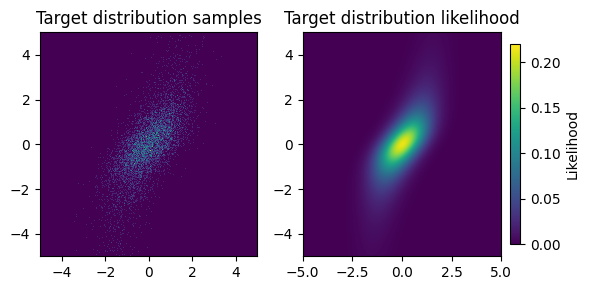

In [3]:
# Sample from target
x_np = target.sample(32000).detach().cpu().numpy()

# Compute likelihood on grid
target_log_p = target.log_prob(grid)
target_likelihood = torch.exp(target_log_p).reshape(grid_size, grid_size)
target_likelihood = target_likelihood.detach().cpu().numpy()

# Create plots
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].hist2d(x_np[:, 0], x_np[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0].set_title('Target distribution samples')
axs[1].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis', vmin=0,vmax=0.22)
# add colorbar to right of axs[1]
cbar = fig.colorbar(axs[1].images[0], ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Likelihood')
axs[1].set_title('Target distribution likelihood')
fig.tight_layout()
fig.show()

In [4]:
# quick estimate of entropy of target distribution, for lower bound on loss
entropy_estimate = -target.log_prob(target.sample(500000)).mean().detach().cpu().numpy()
print("Estimated entropy of target distribution: ", entropy_estimate)
print("Later we use it per dimension (WHY?) so we divide by 2: ", entropy_estimate/2.0)

Estimated entropy of target distribution:  2.9650889446359745
Later we use it per dimension (WHY?) so we divide by 2:  1.4825444723179872


### Fit NF models
We train discrete Neural Spline Flow (NSF) models here:

In [ ]:
# Prepare flow layers for NSF models
def build_flows():
    flows = []
    for _ in range(num_layers):
        
        flows += [
            nf.flows.AutoregressiveRationalQuadraticSpline(
                num_input_channels=2,
                num_hidden_channels=num_hidden_channels,
                num_blocks=num_blocks,
                init_identity=True,
            ),

            nf.flows.ActNorm(2),

            nf.flows.LULinearPermute(2),
        ]
    return flows


# Training algorithm
def train(nf_model: nf.NormalizingFlow, target: Target, num_steps: int = 1000, batch_size: int = 1024, show_every: Optional[int] = None, lr: float = 1e-4, weight_decay: float = 1e-5):
    """ Train the model on target distribution.

    Args:
        nf_model (nf.NormalizingFlow): NF model to train.
        target (Target): Target distribution to train the model on.
        num_steps (int, optional): Number of training steps. Defaults to 1000.
        batch_size (int, optional): Defaults to 2**9.
        show_every (int, optional): Period for visualizing intermediate results (only for 2dim). If None, no intermediate results are computed. Defaults to None.
        lr (float, optional): Learning rate for optimizer. Defaults to 1e-3.
        weight_decay (float, optional): Weight decay for optimizer. Defaults to 1e-5.
    """

    # Prepare loss history
    loss_hist = np.array([])

    # Get training samples for initial loss
    x = target.sample(batch_size).float().to(device)
    # Compute and log initial loss
    loss = nf_model.forward_kld(x)
    loss_hist = np.append(loss_hist, loss.to('cpu').item())

    # Training loop
    optimizer = torch.optim.AdamW(nf_model.parameters(), lr=lr, weight_decay=weight_decay)

    # Initialize the actnorm layers
    calibration_batch = target.sample(2048).to(dtype=DEFAULT_DTYPE, device=device)
    nf_model.train()
    with torch.no_grad():
        for flow in nf_model.flows:
            _ = nf_model.forward_kld(calibration_batch)
    print("ActNorm layers calibrated..")

    pbar = tqdm(range(num_steps), desc="Training the flow")
    for step in pbar:
        optimizer.zero_grad()
        
        # Get training batch
        x = target.sample(batch_size).to(dtype=DEFAULT_DTYPE, device=device)
        
        # Compute loss
        loss = nf_model.forward_kld(x)
        
        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()

            # clip grad norm to stabilize training... 
            torch.nn.utils.clip_grad_norm_(
                    nf_model.parameters(),
                    max_norm=5.0,
                )

            optimizer.step()

        # log loss
        loss_hist = np.append(loss_hist, loss.to('cpu').item())
        pbar.set_postfix({"running loss": loss_hist[-100:].mean()})

        # Compute and show intermediate results
        if show_every is not None and step % show_every == 0:
            nf_model.eval()
            # Sample from model
            samples, _ = nf_model.sample(16000)
            samples = samples.detach().cpu().numpy()
            # Compute likelihood on grid
            log_prob = nf_model.log_prob(grid)
            prob = torch.exp(log_prob).reshape(grid_size, grid_size)
            prob[torch.isnan(prob)] = 0
            prob = prob.detach().cpu().numpy()
            nf_model.train()

            # Visualize flow distribution
            fig, axs = plt.subplots(1, 3, figsize=(9, 3))
            axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
            axs[0].set_title("Flow samples")
            axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis', vmin=0,vmax=0.22)
            axs[1].set_title("Flow likelihood")
            # also add the target distribution for comparison
            axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis', vmin=0,vmax=0.22)
            # add colorbar to right of axs[2]
            cbar = fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('Likelihood')
            axs[2].set_title('Target likelihood')
            print(f"Current training loss: {loss.to('cpu').data.numpy():.3f}")
            plt.tight_layout()
            plt.show()

            # Print TTF params
            last_layer = nf_model.flows[-1]
            if isinstance(last_layer, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
                print("pos_tail: ", last_layer.pos_tail)
                print("neg_tail: ", last_layer.neg_tail)
                print("shift: ", last_layer.shift)
                print("scale: ", last_layer.scale)
                if isinstance(last_layer, ModifiedTailAffineMarginalTransform) and last_layer.mod in ["erfi", "lin"]:
                    if last_layer.a_pos.requires_grad:
                        print("a_pos: ", last_layer.a_pos)
                    if last_layer.a_neg.requires_grad:
                        print("a_neg: ", last_layer.a_neg)
                

    # Plot loss history
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    ax.plot(loss_hist, label='loss')
    ax.set_ylim(min(loss_hist)*0.8, max(np.clip(loss_hist, None, 10.0)*1.2))
    ax.set_title('Training loss')
    # add lower bound on loss based on entropy of target distribution
    ax.axhline(entropy_estimate, color='gray', linestyle='--', label='lower bound (entropy)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Plot final distribution
    nf_model.eval()
    samples, _ = nf_model.sample(32000)
    samples = samples.detach().cpu().numpy()
    log_prob = nf_model.log_prob(grid)
    prob = torch.exp(log_prob).reshape(grid_size, grid_size)
    prob[torch.isnan(prob)] = 0
    prob = prob.detach().cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
    axs[0].set_title('Learned distribution samples')
    axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=0.22)
    axs[1].set_title('Learned distribution likelihood')
    # also add the target distribution for comparison
    axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=0.22)
    axs[2].set_title('Target distribution likelihood')
    # add colorbar to right of axs[2]
    cbar = fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Likelihood')
    plt.tight_layout()
    plt.show()

    # Print final TTF params
    last_layer = nf_model.flows[-1]
    if isinstance(last_layer, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
        print("pos_tail: ", last_layer.pos_tail)
        print("neg_tail: ", last_layer.neg_tail)
        print("shift: ", last_layer.shift)
        print("scale: ", last_layer.scale)
        if isinstance(last_layer, ModifiedTailAffineMarginalTransform) and last_layer.mod in ["erfi", "lin"]:
            if last_layer.a_pos.requires_grad:
                print("a_pos: ", last_layer.a_pos)
            if last_layer.a_neg.requires_grad:
                print("a_neg: ", last_layer.a_neg)


# NLL computation
def get_average_nll(nf_model: nf.NormalizingFlow, target: Target, num_samps: int = 16000) -> float:
    """ Compute average NLL per target sample and dimension.

    Args:
        target (Target): Target distribution.
        num_samps (int, optional): Number of independent samples drawn from target distribution to compute average NLL on. Defaults to 16000.

    Returns:
        nll (float): Average NLL per sample and dimension.
    """
    x1 = target.sample(num_samps)
    total_log_p = nf_model.log_prob(x1.to(dtype=DEFAULT_DTYPE, device=device)).sum().item()

    # Average total NLL over samples and dimension
    nll = -total_log_p / (num_samps * x1.shape[-1])
    return nll


# Count samples in bin
def bin_count(nf_model: nf.NormalizingFlow, target: Target, dim: int, bin: Optional[tuple] = None, num_samps: int = 32000, repeats: int = 8) -> tuple[tuple[float, float], tuple[float, float]]:
    """
    Compute average number of true samples and flow samples in bin for specified dimension.

    Args:
        nf_model (nf.NormalizingFlow): NF model.
        target (Target): Target distribution.
        dim (int): Dimension in which to count.
        bin (tuple[float, float], optional): Interval (bin) in which to count samples. If given None, defaults to small interval around shift of final tail transform. Defaults to None.
        num_samps (int, optional): Number of independent samples drawn from both target and flow distribution. Defaults to 16000.
        repeats (int, optional): Number of repeats to average results over. Defaults to 8.

    Returns:
        (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin) (tuple[tuple[float, float], tuple[float, float]]): Results for target and flow samples (mean, std).
    """
    if bin is None:
        # Set default bin around shift of final transformation
        last_layer = nf_model.flows[-1]
        if isinstance(last_layer, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
            mu = last_layer.shift[dim].to(DEFAULT_DTYPE).item()
            bin = (mu - 0.1, mu + 0.1)
        else:
            bin = (-0.1, 0.1)

    print(f"bin ({bin[0]:.3f}, {bin[1]:.3f}) for dim {dim}:")

    # compute average number of samples in bin for true samples and flow samples
    results_true = []
    results_flow = []
    for i in tqdm(range(repeats)):
        true_samps = target.sample(num_samps)
        flow_samps, _ = nf_model.sample(num_samps)
        true_samps = true_samps[:, dim]
        flow_samps = flow_samps[:, dim]
        num_true_in_bin = ((bin[0] < true_samps) & (true_samps < bin[1])).sum().item()
        num_flow_in_bin = ((bin[0] < flow_samps) & (flow_samps < bin[1])).sum().item()
        results_true.append(num_true_in_bin)
        results_flow.append(num_flow_in_bin)

    avg_num_true_in_bin = float(np.mean(results_true))
    std_num_true_in_bin = float(np.std(results_true))
    avg_num_flow_in_bin = float(np.mean(results_flow))
    std_num_flow_in_bin = float(np.std(results_flow))

    return (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin)

### Baseline (NSF without tail trafo):

In [6]:
# Construct flow model
nfm_baseline = nf.NormalizingFlow(q0=q0, flows=build_flows())
nfm_baseline = nfm_baseline.to(device)

# Print number of parameters
num_params_baseline = sum(p.numel() for p in nfm_baseline.parameters() if p.requires_grad)
print(f"Num params nfm_baseline: ", num_params_baseline)

Num params nfm_baseline:  145888


ActNorm layers calibrated..


Training the flow:   0%|          | 0/2000 [00:00<?, ?it/s, running loss=3.7]

Current training loss: 3.701


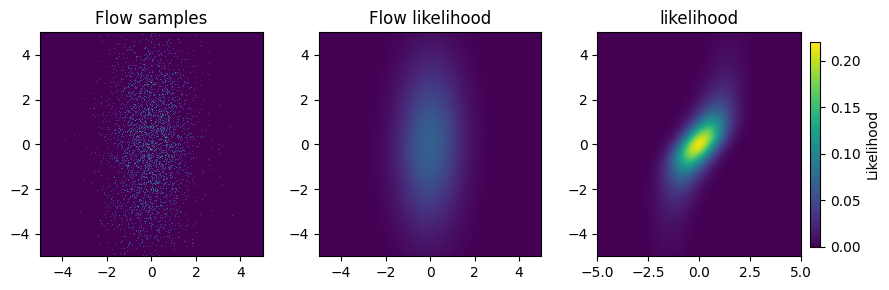

Training the flow:  20%|█▉        | 398/2000 [00:20<01:17, 20.57it/s, running loss=4.04]

Current training loss: 3.514


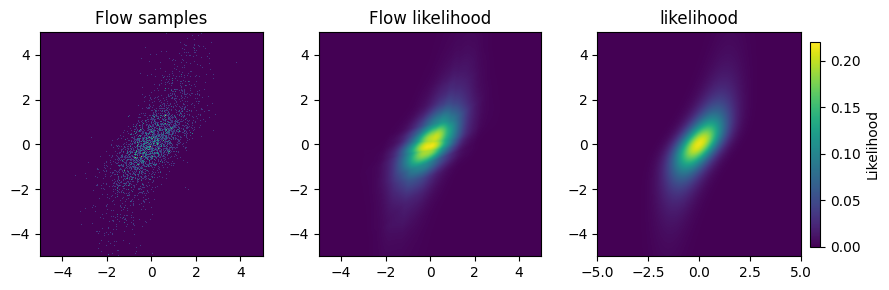

Training the flow:  32%|███▏      | 634/2000 [00:32<01:07, 20.16it/s, running loss=3.61]

In [ ]:
# Train model
train(nfm_baseline, target, 2000, show_every=400)

In [ ]:
# Compute average NLL per sample and dim
nll_baseline = get_average_nll(nfm_baseline, target, 64000)
print(f"Average NLL (per dim!): {nll_baseline:.3f}")

# Count samples in bin around 0
(avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = bin_count(nf_model=nfm_baseline, target=target, dim=0)
print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ± {std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} ± {std_flow_samps_in_bin_dim0:.0f}")
(avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = bin_count(nf_model=nfm_baseline, target=target, dim=1)
print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ±{std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} ± {std_flow_samps_in_bin_dim1:.0f}")

Average NLL (per dim!): 1.535
bin (-0.100, 0.100) for dim 0:


100%|██████████| 8/8 [00:02<00:00,  2.96it/s]


Average num true samps, num flow samps in bin (dim 0): 2501.8 (49.8), 2422.5 (41.0)
bin (-0.100, 0.100) for dim 1:


100%|██████████| 8/8 [00:02<00:00,  3.02it/s]

Average num true samps, num flow samps in bin (dim 1): 2274.8 (41.4), 2000.8 (43.3)


### TTF models

In [ ]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

# Standard TTF
ttf_layer = ModifiedTailAffineMarginalTransform(
    features = 2,
    pos_tail_init = pos_tail_init.detach().clone(),
    neg_tail_init = neg_tail_init.detach().clone(),
    shift_init = shift_init.detach().clone(),
    scale_init = scale_init.detach().clone(),
    hd_only = False,
    mod = "std",
    fix_params = False,
)

# Construct flow model
nfm_ttf = nf.NormalizingFlow(q0=q0, flows=build_flows() + [ttf_layer])
nfm_ttf = nfm_ttf.to(device)

# Print number of parameters
num_params_ttf = sum(p.numel() for p in nfm_ttf.parameters() if p.requires_grad)
print(f"Num params nfm_ttf: ", num_params_ttf)

Standard TTF: No breaking points needed, thus fixed.
Fixed breakpoint params.
Num params nfm_ttf:  145896


ActNorm layers calibrated..


Training the flow:   0%|          | 0/2000 [00:00<?, ?it/s, running loss=3.41]

Current training loss: 3.460


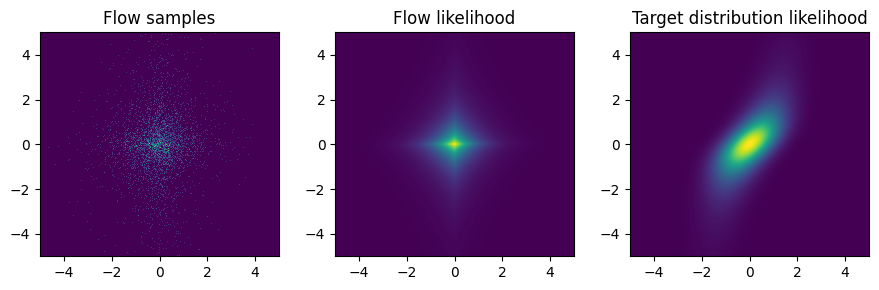

Training the flow:   0%|          | 3/2000 [00:00<06:37,  5.03it/s, running loss=3.36]

pos_tail:  tensor([0.0010, 0.5000], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0010, 0.5000], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([1.0000e-04, 1.0000e-04], device='cuda:3', requires_grad=True)
scale:  tensor([1.0009, 1.0009], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  20%|█▉        | 399/2000 [00:20<01:20, 19.79it/s, running loss=3]   

Current training loss: 2.961


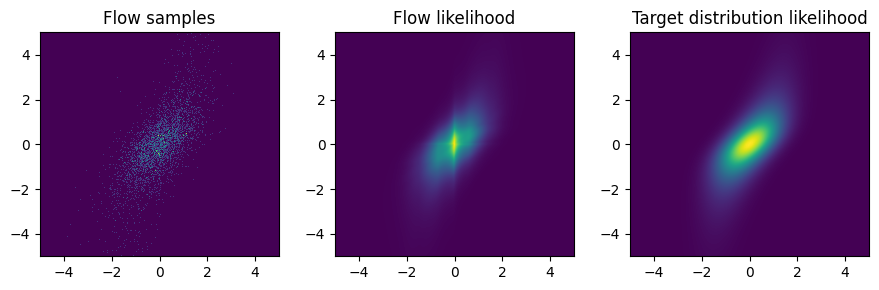

Training the flow:  20%|██        | 403/2000 [00:21<02:52,  9.24it/s, running loss=3]   

pos_tail:  tensor([0.0010, 0.4846], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0010, 0.4850], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([0.0004, 0.0006], device='cuda:3', requires_grad=True)
scale:  tensor([0.9761, 0.9787], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  40%|███▉      | 799/2000 [00:41<01:00, 19.76it/s, running loss=2.98]

Current training loss: 2.945


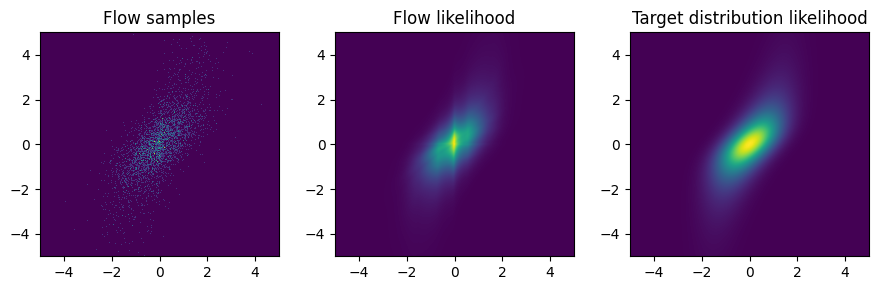

Training the flow:  40%|████      | 803/2000 [00:42<02:09,  9.27it/s, running loss=2.98]

pos_tail:  tensor([0.0009, 0.4705], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0009, 0.4710], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-1.0479e-04,  4.2374e-05], device='cuda:3', requires_grad=True)
scale:  tensor([0.9530, 0.9602], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  60%|█████▉    | 1199/2000 [01:03<00:42, 18.92it/s, running loss=2.98]

Current training loss: 3.019


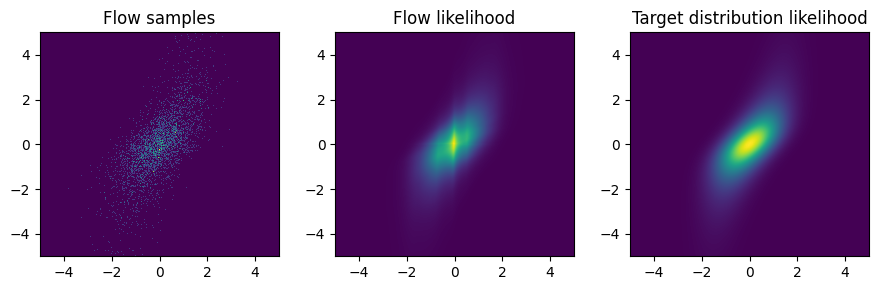

Training the flow:  60%|██████    | 1203/2000 [01:04<01:27,  9.13it/s, running loss=2.99]

pos_tail:  tensor([0.0009, 0.4572], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0009, 0.4580], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-0.0020,  0.0021], device='cuda:3', requires_grad=True)
scale:  tensor([0.9313, 0.9471], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  80%|███████▉  | 1599/2000 [01:25<00:21, 18.83it/s, running loss=2.97]

Current training loss: 2.981


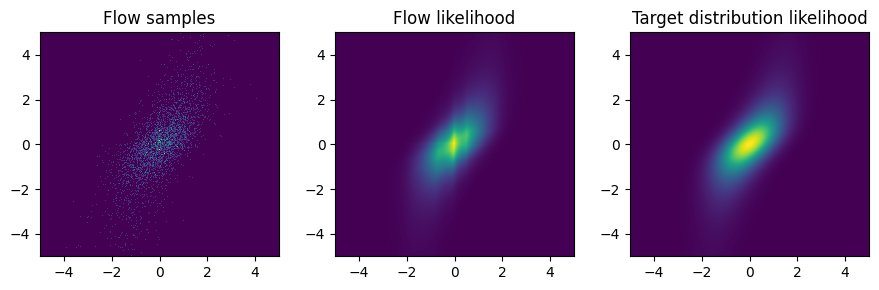

Training the flow:  80%|████████  | 1603/2000 [01:26<00:43,  9.10it/s, running loss=2.97]

pos_tail:  tensor([0.0009, 0.4447], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0009, 0.4452], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-0.0020, -0.0013], device='cuda:3', requires_grad=True)
scale:  tensor([0.9112, 0.9375], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow: 100%|██████████| 2000/2000 [01:46<00:00, 18.70it/s, running loss=2.98]


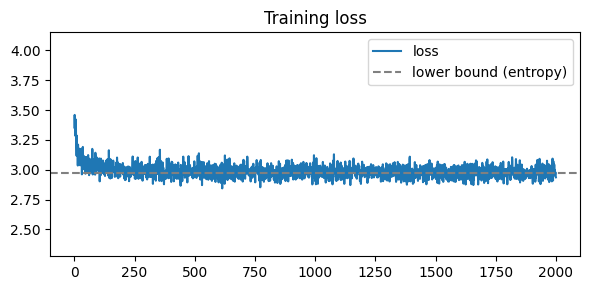

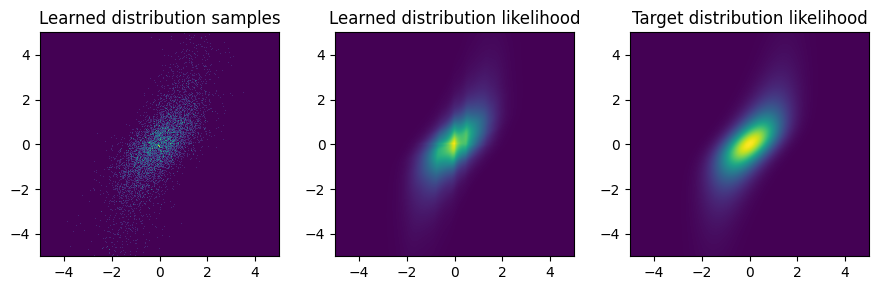

pos_tail:  tensor([0.0008, 0.4329], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0008, 0.4334], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-0.0005, -0.0031], device='cuda:3', requires_grad=True)
scale:  tensor([0.8928, 0.9323], device='cuda:3', grad_fn=<AddBackward0>)


In [ ]:
# train model
train(nfm_ttf, target, 2000, show_every=400)

In [ ]:
# Compute average NLL per sample and dim
nll_ttf = get_average_nll(nfm_ttf, target, 64000)
print(f"Average NLL: {nll_ttf:.3f}")

# Count samples in bin around 0
(avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = bin_count(nf_model=nfm_ttf, target=target, dim=0)
print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ± {std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} ± {std_flow_samps_in_bin_dim0:.0f}")
(avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = bin_count(nf_model=nfm_ttf, target=target, dim=1)
print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ±{std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} ± {std_flow_samps_in_bin_dim1:.0f}")

Average NLL: 1.487
bin (-0.101, 0.099) for dim 0:


100%|██████████| 8/8 [00:02<00:00,  2.99it/s]


Average num true samps, num flow samps in bin (dim 0): 2572.4 (60.5), 2803.9 (40.5)
bin (-0.103, 0.097) for dim 1:


100%|██████████| 8/8 [00:02<00:00,  2.98it/s]

Average num true samps, num flow samps in bin (dim 1): 2262.4 (49.5), 2267.8 (44.9)


### Modified TTF versions

In [ ]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

# TTF layer with modifications
ttf_mod_layer = ModifiedTailAffineMarginalTransform(
    features = 2,
    pos_tail_init = pos_tail_init.detach().clone(),
    neg_tail_init = neg_tail_init.detach().clone(),
    shift_init = shift_init.detach().clone(),
    scale_init = scale_init.detach().clone(),
    hd_only = True,
    mod = "qua",
    fix_params = False,
)

# Construct flow model
nfm_ttf_mod = nf.NormalizingFlow(q0=q0, flows=build_flows() + [ttf_mod_layer])
nfm_ttf_mod = nfm_ttf_mod.to(device)

# Print number of parameters
num_params_ttf_mod = sum(p.numel() for p in nfm_ttf_mod.parameters() if p.requires_grad)
print(f"Num params nfm_ttf_mod: ", num_params_ttf_mod)

Quadratic-slope TTF modification currently only works with fixed tailparams and breaking points (TTFfix). Also, breaking points are computed automatically (overwriting user inputs for these parameters) to ensure invertibility.
Compute a_neg to ensure invertibility...
Computed a_neg:  tensor([-0.6279, -0.9465])
Compute a_pos to ensure invertibility...
Computed a_pos:  tensor([0.6279, 0.9465])
Quadratic-derivative TTF: Fix tailparams and breaking points.
Fixed tailparams.
Fixed breakpoint params.
Num params nfm_ttf_mod:  145892


ActNorm layers calibrated..


Training the flow:   0%|          | 0/2000 [00:00<?, ?it/s, running loss=3.42]

Current training loss: 3.352


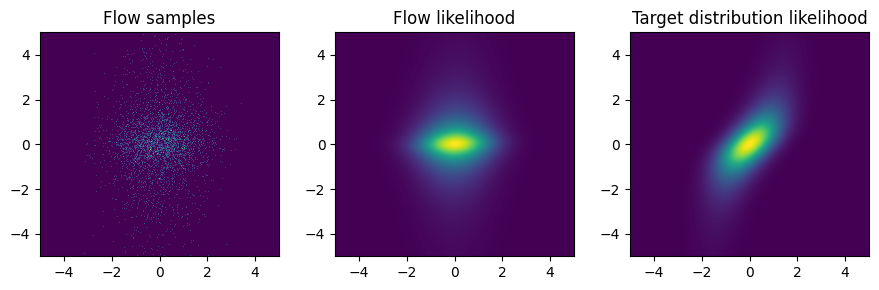

Training the flow:   0%|          | 3/2000 [00:00<06:53,  4.83it/s, running loss=3.38]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([1.0000e-04, 1.0000e-04], device='cuda:3', requires_grad=True)
scale:  tensor([1.0009, 1.0009], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  20%|█▉        | 399/2000 [00:23<01:31, 17.57it/s, running loss=2.98]

Current training loss: 2.908


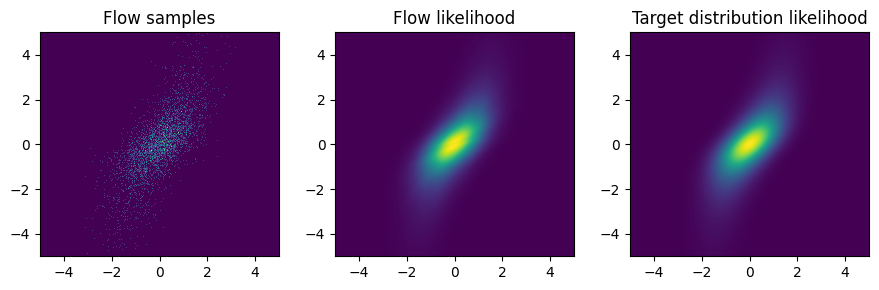

Training the flow:  20%|██        | 403/2000 [00:24<03:02,  8.74it/s, running loss=2.98]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([-0.0004, -0.0006], device='cuda:3', requires_grad=True)
scale:  tensor([0.9974, 0.9753], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  40%|███▉      | 799/2000 [00:46<01:06, 18.05it/s, running loss=2.98]

Current training loss: 2.950


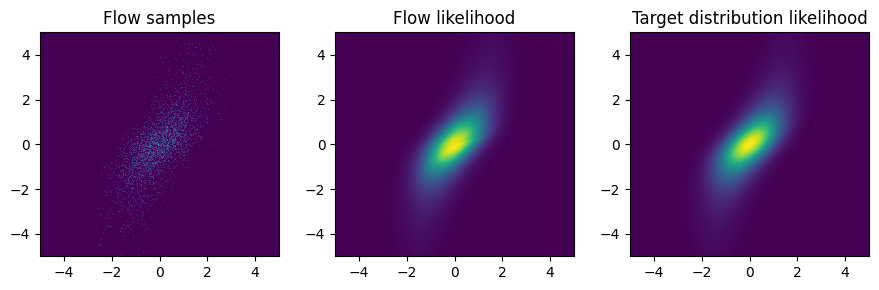

Training the flow:  40%|████      | 803/2000 [00:47<02:33,  7.79it/s, running loss=2.98]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([-2.2225e-04, -8.9917e-06], device='cuda:3', requires_grad=True)
scale:  tensor([1.0001, 0.9510], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  60%|█████▉    | 1199/2000 [01:10<00:44, 17.84it/s, running loss=2.98]

Current training loss: 2.924


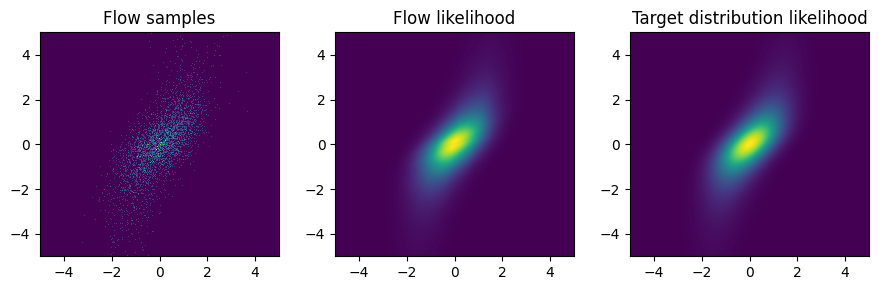

Training the flow:  60%|██████    | 1203/2000 [01:10<01:30,  8.84it/s, running loss=2.98]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([-0.0005,  0.0010], device='cuda:3', requires_grad=True)
scale:  tensor([1.0021, 0.9273], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  80%|███████▉  | 1599/2000 [01:33<00:23, 17.12it/s, running loss=2.98]

Current training loss: 3.013


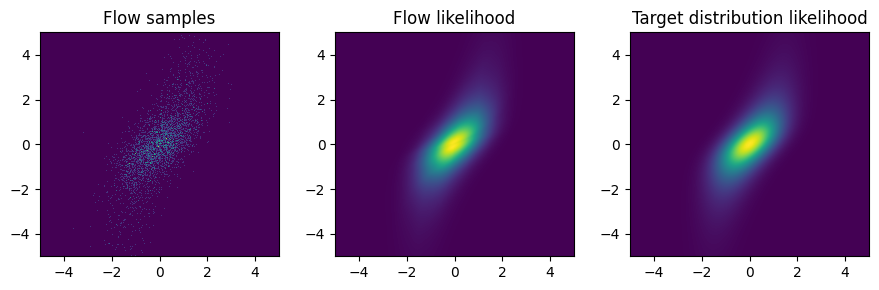

Training the flow:  80%|████████  | 1603/2000 [01:34<00:45,  8.69it/s, running loss=2.98]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([-0.0005,  0.0007], device='cuda:3', requires_grad=True)
scale:  tensor([1.0036, 0.9041], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow: 100%|██████████| 2000/2000 [01:57<00:00, 17.03it/s, running loss=2.97]


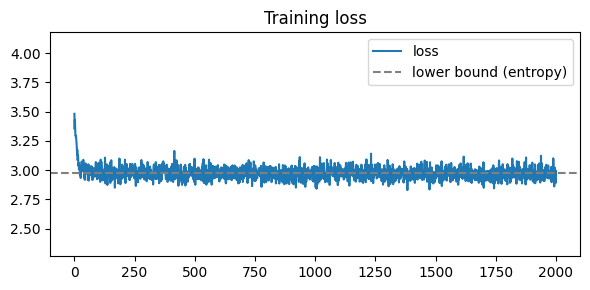

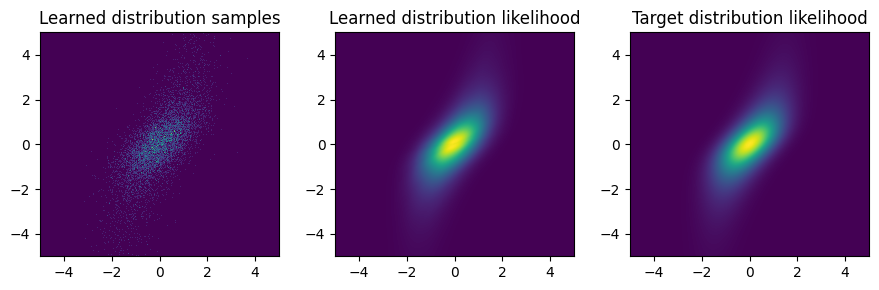

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([-0.0010,  0.0011], device='cuda:3', requires_grad=True)
scale:  tensor([1.0052, 0.8817], device='cuda:3', grad_fn=<AddBackward0>)


In [ ]:
# Train model
train(nfm_ttf_mod, target, 2000, show_every=400)

In [ ]:
# Compute average NLL per sample and dim
nll_ttf_mod = get_average_nll(nfm_ttf_mod, target, 64000)
print(f"Average NLL: {nll_ttf_mod:.3f}")

# Count samples in bin around 0
(avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = bin_count(nf_model=nfm_ttf_mod, target=target, dim=0)
print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ± {std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} ± {std_flow_samps_in_bin_dim0:.0f}")
(avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = bin_count(nf_model=nfm_ttf_mod, target=target, dim=1)
print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ±{std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} ± {std_flow_samps_in_bin_dim1:.0f}")

Average NLL: 1.486
bin (-0.101, 0.099) for dim 0:


100%|██████████| 8/8 [00:02<00:00,  2.82it/s]


Average num true samps, num flow samps in bin (dim 0): 2518.4 (39.1), 2552.5 (59.7)
bin (-0.099, 0.101) for dim 1:


100%|██████████| 8/8 [00:02<00:00,  2.99it/s]

Average num true samps, num flow samps in bin (dim 1): 2251.1 (45.9), 2226.0 (40.3)


## Compare Flow Matching Models

### Define FM vector fields:

In [ ]:
import torch.nn as nn
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper

# Sinusoidal time embedding
class TimeEmbedding(nn.Module):
    def __init__(self, time_emb_dim: int):
        super().__init__()
        self.time_emb_dim = time_emb_dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Embed 1-d time into {time_emb_dim}-dimensional space.

        Args:
            t (torch.Tensor): Shape [batch] or [batch, 1].

        Returns:
            temb (torch.Tensor): Shape [batch, time_emb_dim].
        """
        if t.dim() == 1:
            t = t[:, None]

        half_dim = self.time_emb_dim // 2
        freqs = torch.exp(
            torch.linspace(
                0,
                torch.log(torch.tensor(1000.0, device=t.device)),
                half_dim,
                device=t.device,
            )
        )
        args = t * freqs[None, :] * 2.0 * torch.pi
        temb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.time_emb_dim % 2 == 1:
            temb = torch.cat([temb, t], dim=-1)

        return temb


# Residual layer with smooth SiLU activation
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, hidden_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Shape [batch, dim]

        Returns:
            torch.Tensor: Shape [batch, dim]
        """
        return x + self.net(x)


# Time-dependent vector field for Flow Matching models
class FMVectorField(nn.Module):
    def __init__(
        self,
        x_dim: int = 2,
        hidden_dim: int = 64,
        num_blocks: int = 4,
        time_emb_dim: int = 16,
    ):
        super().__init__()

        self.x_dim = x_dim
        self.time_embedding = TimeEmbedding(time_emb_dim)

        input_dim = x_dim + time_emb_dim

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
        )

        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, hidden_dim)
            for _ in range(num_blocks)
        ])

        self.output_layer = nn.Linear(hidden_dim, x_dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Shape [batch, x_dim].
            t (torch.Tensor): Shape [batch] or [batch, 1].

        Returns:
            v (torch.Tensor): Velocity vector field at point x and time t (shape [batch, x_dim]).
        """

        # Ensure t has the same batch size as x
        if t.dim() == 0:  # scalar
            t = t.expand(x.shape[0])
        elif t.dim() == 1 and t.shape[0] == 1:
            t = t.expand(x.shape[0])
        
        temb = self.time_embedding(t)
        h = torch.cat([x, temb], dim=-1)

        h = self.input_layer(h)

        for block in self.blocks:
            h = block(h)

        v = self.output_layer(h)
        return v

### Define FM loss:

In [ ]:
# Conditional FM loss for linear Gaussian prob. paths
mse_loss = nn.MSELoss()
def cfm_loss(vf: FMVectorField, x1: torch.Tensor, q0: nf.distributions.BaseDistribution) -> torch.Tensor:
    """
    Conditional Flow Matching loss for linear (OT) Gaussian Probability Path.

    Args:
        vf (FMVectorField): FM vector field.
        x1 (torch.Tensor): Data batch (shape: [batch_size, features]).
        q0 (nf.distributions.BaseDistribution): Base distribution of the FM model (Usually N(0,I)).

    Returns:
        loss (torch.Tensor): loss on data batch (shape: []).
    """
    batch_size = x1.shape[0]
    device = x1.device

    # Instantiate OT probability path
    path = AffineProbPath(scheduler=CondOTScheduler())

    # sample from base distribution
    x0, _ = q0.forward(batch_size)
    x0 = x0.to(dtype=DEFAULT_DTYPE, device=device)

    # sample time uniformly
    t = torch.rand(batch_size, device=device).to(device)

    # Sample probability path
    path_sample = path.sample(x0, x1, t)

    # Conditional FM l2 loss
    loss = mse_loss(vf(path_sample.x_t.to(device), path_sample.t.to(device)), path_sample.dx_t.to(device))

    return loss

### Add final TTF layer:

In [ ]:
class IdentityTransform(Transform):
    """ Identity function in feature space. """

    def __init__(self, features: int):
        super().__init__()
        self.features = features

    def forward(self, z: torch.Tensor, context=None) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            z (torch.Tensor): Shape [batch, features].

        Returns:
            z, lad (tuple[torch.Tensor, torch.Tensor]): lad (=0) is summed over dimension: Shape [batch].
        """
        lad = torch.zeros_like(z)
        return z, lad.sum(dim=-1)

    def inverse(self, x: torch.Tensor, context=None) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x (torch.Tensor): Shape [batch, features].

        Returns:
            x, lad (tuple[torch.Tensor, torch.Tensor]): lad (=0) is summed over dimension: Shape [batch].
        """
        lad = torch.zeros_like(x)
        return x, lad.sum(dim=-1)
    

class FM_TTF_model(torch.nn.Module):
    """ Implementation of a Flow Matching model together with an optional final tail (TTF) transformation. """

    def __init__(self, device: torch.device, vf: FMVectorField, q0: nf.distributions.BaseDistribution, tail_trafo: Optional[Transform] = None):
        """
        Build combined model consisting of a FM velocity field and a final tail transformation.

        Args:
            device (torch.device): Device.
            vf (FMVectorField): Flow Matching velocity field.
            q0 (nf.distributions.BaseDistribution): Base distribution of the FM model.
            tail_trafo (Transform, optional): Final tail transformation. If given None, the identity transformation is used. Defaults to None.
        """
        super().__init__()
        self.features = vf.x_dim
        self.device = device
        self.vf = vf.to(device)
        self.q0 = q0.to(device)
        if tail_trafo is None:
            tail_trafo = IdentityTransform(features=vf.x_dim) # Default: Identity Transformation
        self.tail_trafo = tail_trafo.to(device)

        assert self.features == self.tail_trafo.features, f"Mismatch in dimension of vf ({self.features}) and dimension of tail_trafo ({self.tail_trafo.features})."

        # Fix TTF params
        if isinstance(self.tail_trafo, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
            print("Currently, learning the TTF params is not possible for FM-TTF models. Therefore, TTF params will be fixed.")
            if isinstance(self.tail_trafo, ModifiedTailAffineMarginalTransform):
                self.tail_trafo.fix_all()
            elif isinstance(self.tail_trafo, TailAffineMarginalTransform):
                self.tail_trafo.fix_tails()
                print("Fixed tailparams.")
                self.tail_trafo.shift.requires_grad = False
                print("Fixed location params.")
                self.tail_trafo._unc_scale.requires_grad = False
                print("Fixed scale params.")

    @torch.no_grad()
    def sample(self, num_samps: int, method: str = "dopri5", step_size: Optional[float] = None, **ode_extras) -> torch.Tensor:
        """ Sample from model.

        Args:
            num_samps (int): Number of samples.
            method (str, optional): Method for ODE solver. Defaults to "dopri5".
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            x1 (torch.Tensor): Samples (shape: [num_samps, self.features])
        """
        # Sample from base distribution
        x0 = self.q0.sample(num_samps)
        if isinstance(x0, tuple):
            x0 = x0[0] # take only samples, not log_prob
        x0 = x0.to(self.device)

        # Solve forward ODE
        solver = ODESolver(ModelWrapper(self.vf))
        y = solver.sample(x0, step_size=step_size, method=method, **ode_extras)

        # Apply tail transformation
        x1, _ = self.tail_trafo.forward(y)

        return x1

    @torch.no_grad()
    def log_prob(self, x1: torch.Tensor, method: str = "dopri5", exact_divergence: bool = False, step_size: Optional[float] = None, **ode_extras) -> torch.Tensor:
        """ Compute log_prob on data batch x1.

        Args:
            x1 (torch.Tensor): Data batch (shape: [batch_size, self.features])
            method (str, optional): Method for ODE solver. Defaults to "dopri5".
            exact_divergence (bool, optional): Whether to use exact diversion or Hutchinson estimator in ODE solver. Defaults to False.
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            log_p (torch.Tensor): log prob values for all data points (summed over feature dimension) (shape: [batch]).
        """
        x1 = x1.to(self.device)

        print(f"Computing likelihood on tensor of shape {x1.shape}...")

        # Apply inverse tail transformation
        y, lad = self.tail_trafo.inverse(x1)
        y = y.to(self.device)
        lad = lad.to(self.device)

        # Solve reverse-time ODE
        solver = ODESolver(ModelWrapper(self.vf))
        _ , log_p = solver.compute_likelihood(y, self.q0.log_prob, step_size=step_size, method=method, exact_divergence=exact_divergence, **ode_extras)
        log_p = log_p.to(self.device)

        # Change of variables formula
        log_p = log_p + lad

        return log_p

    @torch.no_grad()
    def get_average_nll(self, target: Target, num_samps: int = 16000, method: str = 'dopri5', batch_size: int = 64000, exact_divergence: bool = True, step_size: Optional[float] = None, **ode_extras) -> float:
        """ Compute average NLL per target sample and dimension. Computation is split in batches to reduce peak usage.

        Args:
            target (Target): Target distribution.
            num_samps (int, optional): Number of independent samples drawn from target distribution to compute average NLL on. Defaults to 16000.
            method (str, optional): Method for ODE sovler. Defaults to 'dopri5'.
            batch_size (int, optional): Size of batches on which likelihood is computed simultaneously. Defaults to 4096.
            exact_divergence (bool, optional): Whether to use exact divergence or Hutchinson estimator in ODE solver. Defaults to True.
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            nll (float): Average NLL per sample and dimension.
        """
        # Sample independent target data points
        x1 = target.sample(num_samps).to(dtype=DEFAULT_DTYPE, device=self.device)

        # Compute log_p in batches
        total_log_p = 0.0

        for start in tqdm(range(0, num_samps, batch_size)):

            # Compute batch log_p
            end = min(start + batch_size, num_samps)
            batch = x1[start:end]
            log_p = self.log_prob(batch, method=method, exact_divergence=exact_divergence, step_size=step_size, **ode_extras)

            # Add to total log_p and delete batch results to free memory
            total_log_p += log_p.sum().item()
            del batch, log_p
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        # Average total NLL over samples and dimension
        nll = -total_log_p / (num_samps * self.features)

        return nll

    def train(self, target: Target, num_steps: int = 1000, batch_size: int = 1024, show_every: Optional[int] = None, lr: float = 1e-4, weight_decay: float = 1e-5):
        """ Train the model on target distribution. Trains only the FM vector field, not the final transformation.

        Args:
            target (Target): Target distribution to train the model on.
            num_steps (int, optional): Number of training steps. Defaults to 1000.
            batch_size (int, optional): Defaults to 512.
            show_every (int, optional): Period for visualizing intermediate results (only for 2dim). If None, no intermediate results are computed. Defaults to None.
            lr (float, optional): Learning rate for optimizer. Defaults to 1e-3.
            weight_decay (float, optional): Weight decay for optimizer. Defaults to 1e-5.
        """
        target = target.to(self.device)

        # Prepare loss history
        loss_hist = np.array([])

        # Get training samples for initial loss
        x = target.sample(batch_size).to(dtype=DEFAULT_DTYPE, device=self.device)
        # Apply inverse tail transform
        y, _ = self.tail_trafo.inverse(x)
        # Compute and log initial loss
        loss = cfm_loss(self.vf, y.to(self.device), self.q0)
        loss_hist = np.append(loss_hist, loss.to('cpu').item())

        # Training loop
        optimizer = torch.optim.AdamW(self.vf.parameters(), lr=lr, weight_decay=weight_decay)

        pbar = tqdm(range(num_steps), desc="Training steps")
        for step in pbar:
            optimizer.zero_grad()

            # Get training batch
            x = target.sample(batch_size).to(dtype=DEFAULT_DTYPE, device=self.device)
            # Apply inverse tail transform
            y, _ = self.tail_trafo.inverse(x)

            # Compute loss
            loss = cfm_loss(self.vf, y, self.q0)

            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()

                # clip grad norm to stabilize training... 
                torch.nn.utils.clip_grad_norm_(
                    self.vf.parameters(),
                    max_norm=5.0,
                )
                optimizer.step()

            # log loss in progress bar
            loss_hist = np.append(loss_hist, loss.to('cpu').item())
            pbar.set_postfix({"running loss": loss_hist[-100:].mean()})

            # Compute and show intermediate results
            if show_every is not None and self.features == 2:
                if step % show_every == 0:
                    # Sample from model
                    samples = self.sample(16000)
                    samples = samples.detach().cpu().numpy()
                    # Compute likelihood on grid
                    log_prob = self.log_prob(grid)
                    prob = torch.exp(log_prob).reshape(grid_size, grid_size)
                    prob[torch.isnan(prob)] = 0
                    prob = prob.detach().cpu().numpy()

                    # Visualize flow distribution
                    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
                    axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
                    axs[0].set_title("Flow samples")
                    axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=0.22)
                    axs[1].set_title("Flow likelihood")
                    # also add the target distribution for comparison
                    axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=0.22)
                    axs[2].set_title('Target distribution likelihood')
                    # add colorbar to right of axs[2]
                    cbar = fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
                    cbar.set_label('Likelihood')
                    print(f"Current training loss: {loss.to('cpu').data.numpy():.3f}")
                    plt.tight_layout()
                    plt.show()

        # Plot loss history
        fig, ax = plt.subplots(1, 1, figsize=(6, 3))
        ax.plot(loss_hist, label='loss')
        ax.set_ylim(min(loss_hist)*0.8, max(np.clip(loss_hist, None, 10.0)*1.2))
        ax.set_title('Training loss')
        # add lower bound on loss based on entropy of target distribution
        ax.axhline(entropy_estimate, color='gray', linestyle='--', label='lower bound (entropy)')
        plt.tight_layout()
        plt.show()

        # Plot final distribution
        if self.features == 2:
            samples = self.sample(32000)
            samples = samples.detach().cpu().numpy()
            log_prob = self.log_prob(grid, exact_divergence=True)
            prob = torch.exp(log_prob).reshape(grid_size, grid_size)
            prob[torch.isnan(prob)] = 0
            prob = prob.detach().cpu().numpy()

            fig, axs = plt.subplots(1, 3, figsize=(9, 3))
            axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
            axs[0].set_title("Flow samples")
            axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
            axs[1].set_title("Flow likelihood")
            axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
            axs[2].set_title("Target distribution likelihood")  
            plt.tight_layout()
            plt.show()

    @torch.no_grad()
    def bin_count(self, target: Target, dim: int, bin: Optional[tuple[float, float]] = None, num_samps: int = 32000, repeats: int = 8,
                  method: str = "dopri5", step_size: Optional[float] = None, **ode_extras) -> tuple[tuple[float, float], tuple[float, float]]:
        """
        Compute average number of true samples and flow samples in bin for specified dimension.

        Args:
            target (Target): Target distribution.
            dim (int): Dimension in which to count.
            bin (tuple[float, float], optional): Interval (bin) in which to count samples. If given None, defaults to small interval around shift of final tail transform. Defaults to None.
            num_samps (int, optional): Number of independent samples drawn from both target and flow distribution. Defaults to 16000.
            repeats (int, optional): Number of repeats to average results over. Defaults to 8.
            method (str, optional): Method for ODE solver. Defaults to "dopri5".
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin) (tuple[tuple[float, float], tuple[float, float]]): Results for target and flow samples (mean, std).
        """
        assert dim >= 0 and dim <= self.features - 1, f"Invalid dimension {dim} for model with {self.features} features."

        if bin is None:
            # Set default bin around shift of final transformation
            mu = 0.0
            if hasattr(self.tail_trafo, 'shift'):
                mu = self.tail_trafo.shift[dim].to(DEFAULT_DTYPE).item() # type: ignore 
            bin = (mu - 0.1, mu + 0.1)

        print(f"bin ({bin[0]:.3f}, {bin[1]:.3f}) for dim {dim}:")

        # Compute average number of samples in bin for target and flow samples
        results_true = []
        results_flow = []
        for i in tqdm(range(repeats)):
            true_samps = target.sample(num_samps)
            flow_samps = self.sample(num_samps, method=method, step_size=step_size, **ode_extras)
            true_samps = true_samps[:, dim]
            flow_samps = flow_samps[:, dim]
            num_true_in_bin = ((bin[0] < true_samps) & (true_samps < bin[1])).sum().item()
            num_flow_in_bin = ((bin[0] < flow_samps) & (flow_samps < bin[1])).sum().item()
            results_true.append(num_true_in_bin)
            results_flow.append(num_flow_in_bin)

        avg_num_true_in_bin = float(np.mean(results_true))
        std_num_true_in_bin = float(np.std(results_true))
        avg_num_flow_in_bin = float(np.mean(results_flow))
        std_num_flow_in_bin = float(np.std(results_flow))

        return (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin)

### FM baseline (without tail transform):

In [ ]:
fm_baseline_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
)

# Print number of parameters
num_params_fm_baseline = sum(p.numel() for p in fm_baseline_model.parameters() if p.requires_grad)
print(f"Num params fm_baseline: ", num_params_fm_baseline)

Num params fm_baseline:  103810


Training steps:   0%|          | 0/3000 [00:00<?, ?it/s, running loss=21.6]

Computing likelihood on tensor of shape torch.Size([250000, 2])...
Current training loss: 30.643


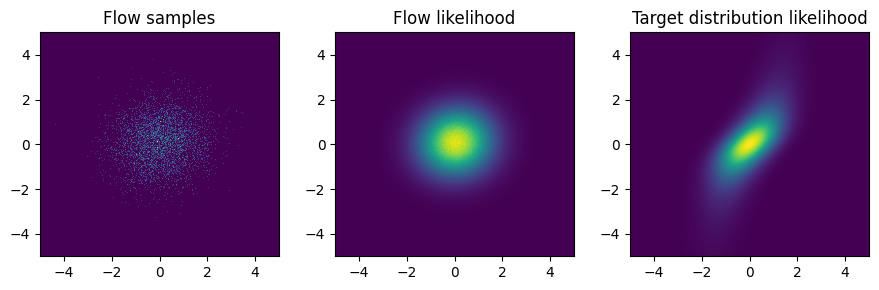

Training steps: 100%|██████████| 3000/3000 [01:05<00:00, 46.04it/s, running loss=6.85]


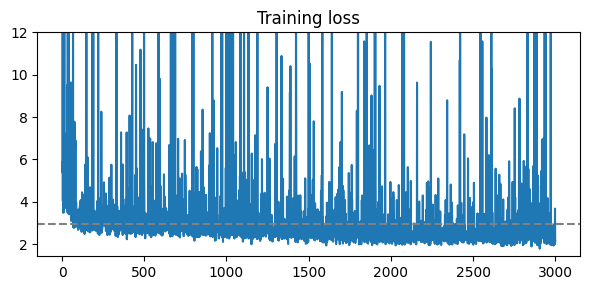

Computing likelihood on tensor of shape torch.Size([250000, 2])...


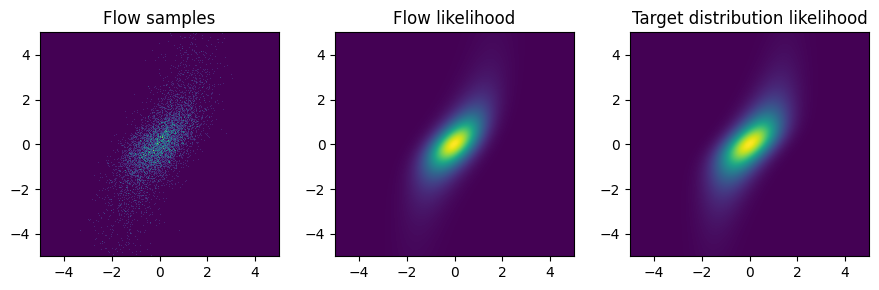

In [ ]:
fm_baseline_model.train(target, 3000, show_every=3000)

In [ ]:
# Compute average NLL per sample and dim
nll_fm_baseline = fm_baseline_model.get_average_nll(target, 64000)
print(f"Average NLL: {nll_fm_baseline:.3f}")

# Count samples in bin around 0
(avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = fm_baseline_model.bin_count(target, 0)
print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ±{std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} vs {std_flow_samps_in_bin_dim0:.0f}")
(avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = fm_baseline_model.bin_count(target, 1)
print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ± {std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} vs {std_flow_samps_in_bin_dim1:.0f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Computing likelihood on tensor of shape torch.Size([64000, 2])...


100%|██████████| 1/1 [00:29<00:00, 29.97s/it]


Average NLL: 1.540
bin (-0.100, 0.100) for dim 0:


100%|██████████| 8/8 [00:35<00:00,  4.43s/it]


Average num true samps, num flow samps in bin (dim 0): 2541.6 (48.5), 2734.2 (43.0)
bin (-0.100, 0.100) for dim 1:


100%|██████████| 8/8 [00:35<00:00,  4.48s/it]

Average num true samps, num flow samps in bin (dim 1): 2267.1 (61.6), 2390.0 (62.9)


<!-- ### FM + TTF model -->

### FM + TTF model

In [ ]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

fm_ttf_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
    ModifiedTailAffineMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = False,
        mod = "std", # "std" or "qua"
        a_pos_init = None,
        a_neg_init = None,
        fix_params = True,
    ),
)

# Print number of parameters
num_params_fm_ttf = sum(p.numel() for p in fm_ttf_model.parameters() if p.requires_grad)
print(f"Num params fm_ttf: ", num_params_fm_ttf)

Fixed tailparams.
Fixed location params.
Fixed scale params.
Fixed breakpoint params.
Currently, learning the TTF params is not possible for FM-TTF models. Therefore, TTF params will be fixed.
Fixed tailparams.
Fixed location params.
Fixed scale params.
Fixed breakpoint params.
Num params fm_ttf:  103810


Training steps:   0%|          | 0/3000 [00:00<?, ?it/s]

Training steps:   0%|          | 0/3000 [00:00<?, ?it/s, running loss=1.79]

Computing likelihood on tensor of shape torch.Size([250000, 2])...
Current training loss: 1.757


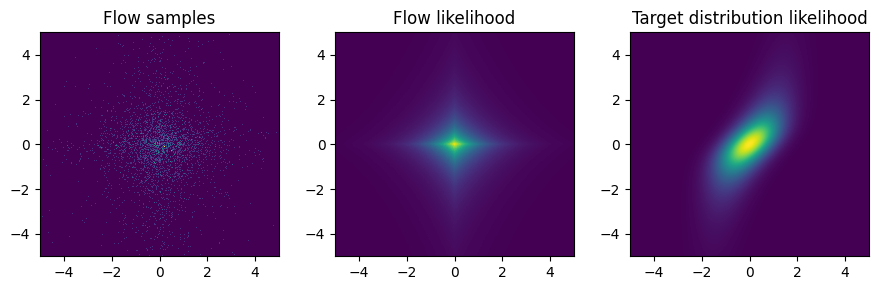

Training steps:  50%|████▉     | 1494/3000 [00:59<00:22, 66.30it/s, running loss=1.25]

Computing likelihood on tensor of shape torch.Size([250000, 2])...


Training steps:  50%|████▉     | 1494/3000 [01:10<00:22, 66.30it/s, running loss=1.25]

Current training loss: 1.274


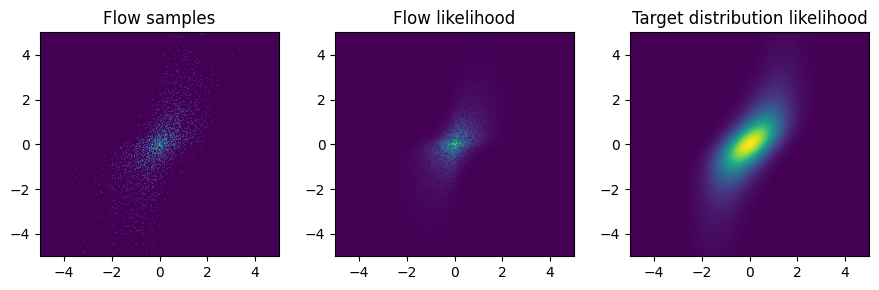

Training steps: 100%|██████████| 3000/3000 [02:09<00:00, 23.23it/s, running loss=1.23]


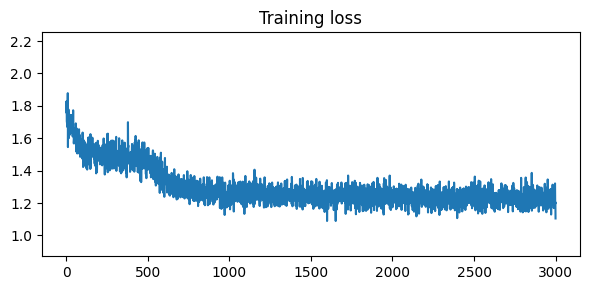

Computing likelihood on tensor of shape torch.Size([250000, 2])...


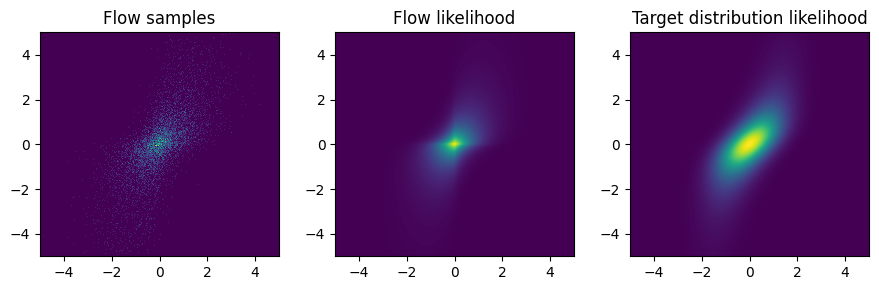

In [ ]:
fm_ttf_model.train(target, 3000, show_every=1500)

In [ ]:
# Compute average NLL per sample and dim
nll_fm_ttf = fm_ttf_model.get_average_nll(target, 64000)
print(f"Average NLL: {nll_fm_ttf:.3f}")

# Count samples in bin around 0
(avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = fm_ttf_model.bin_count(target, 0)
print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ± {std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} ± {std_flow_samps_in_bin_dim0:.0f}")
(avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = fm_ttf_model.bin_count(target, 1)
print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ± {std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} ± {std_flow_samps_in_bin_dim1:.0f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Computing likelihood on tensor of shape torch.Size([64000, 2])...


100%|██████████| 1/1 [00:34<00:00, 34.42s/it]


Average NLL: 1.511
bin (-0.100, 0.100) for dim 0:


100%|██████████| 8/8 [00:27<00:00,  3.47s/it]


Average num true samps, num flow samps in bin (dim 0): 2560 ± 28 vs 3454 ± 42
bin (-0.100, 0.100) for dim 1:


100%|██████████| 8/8 [00:28<00:00,  3.53s/it]

Average num true samps, num flow samps in bin (dim 1): 2246 ± 40 vs 3258 ± 57


### FM + SoftLogMarginalTransform

In [ ]:
# from tailnflows.models.extreme_transformations import SoftLogMarginalTransform

# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

fm_ttflog_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
    SoftLogMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = False,
        mod = "std", # "std" or "qua"
        a_pos_init = None,
        a_neg_init = None,
        fix_params = True,
    ),
)

# Print number of parameters
num_params_fm_ttflog = sum(p.numel() for p in fm_ttflog_model.parameters() if p.requires_grad)
print(f"Num params fm_ttflog: ", num_params_fm_ttflog)

Fixed location params.
Fixed scale params.
Num params fm_ttflog:  103810


Training steps:   0%|          | 0/3000 [00:00<?, ?it/s, running loss=1.62]

Computing likelihood on tensor of shape torch.Size([250000, 2])...
Current training loss: 1.618


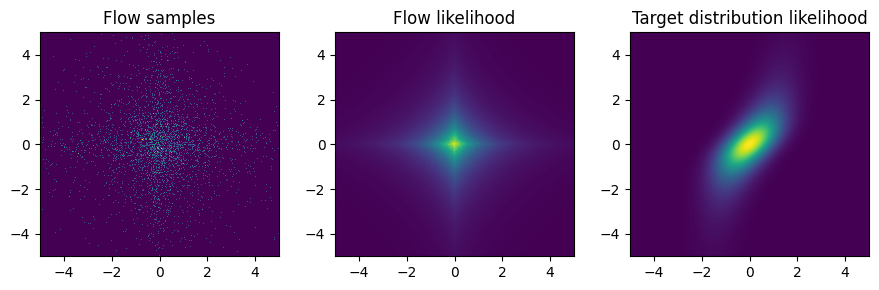

Training steps:  50%|████▉     | 1496/3000 [01:03<00:20, 74.17it/s, running loss=1.1] 

Computing likelihood on tensor of shape torch.Size([250000, 2])...


Training steps:  50%|████▉     | 1496/3000 [01:16<00:20, 74.17it/s, running loss=1.1]

Current training loss: 1.055


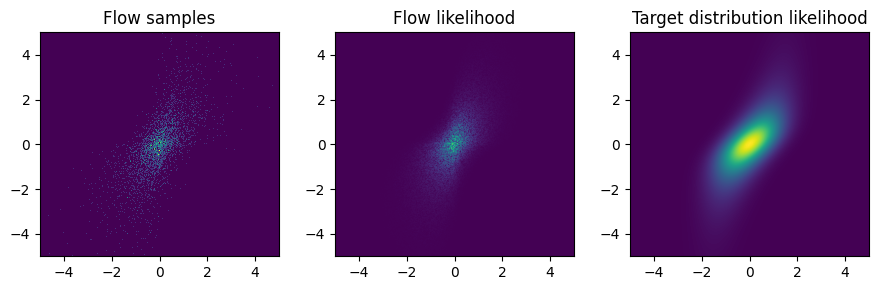

Training steps: 100%|██████████| 3000/3000 [02:12<00:00, 22.69it/s, running loss=1.09]


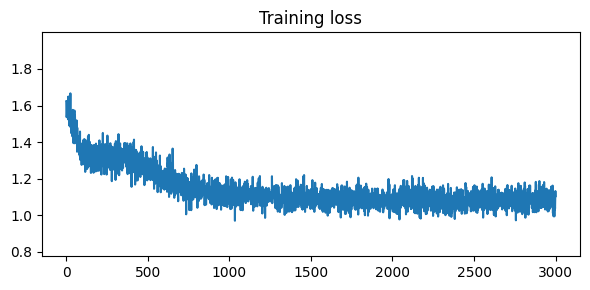

Computing likelihood on tensor of shape torch.Size([250000, 2])...


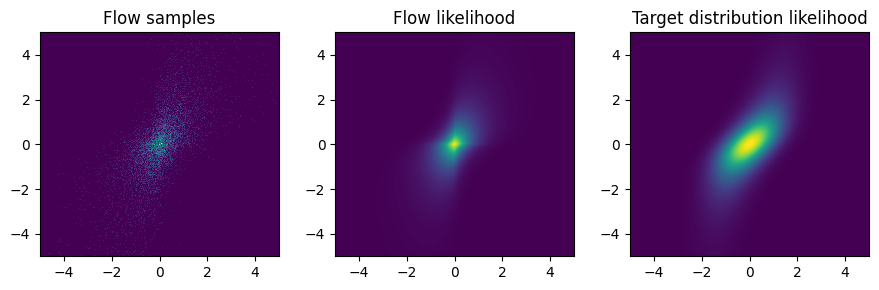

In [ ]:
fm_ttflog_model.train(target, 3000, show_every=1500)

In [ ]:
# Compute average NLL per sample and dim
nll_fm_ttflog = fm_ttflog_model.get_average_nll(target, 64000)
print(f"Average NLL: {nll_fm_ttflog:.3f}")

# Count samples in bin around 0
(avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = fm_ttflog_model.bin_count(target, 0)
print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ± {std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} ± {std_flow_samps_in_bin_dim0:.0f}")
(avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = fm_ttflog_model.bin_count(target, 1)
print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ± {std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} ± {std_flow_samps_in_bin_dim1:.0f}")

  0%|          | 0/1 [00:00<?, ?it/s]/home/dammsicw/tailnflows/.venv/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


Computing likelihood on tensor of shape torch.Size([64000, 2])...


100%|██████████| 1/1 [00:30<00:00, 30.14s/it]


Average NLL: 1.523
bin (-0.100, 0.100) for dim 0:


100%|██████████| 8/8 [00:29<00:00,  3.71s/it]


Average num true samps, num flow samps in bin (dim 0): 2529.4 (29.0), 3834.8 (65.3)
bin (-0.100, 0.100) for dim 1:


100%|██████████| 8/8 [00:29<00:00,  3.66s/it]

Average num true samps, num flow samps in bin (dim 1): 2257.1 ± 51.0, 2834 ±74


### FM + ArcSinhMarginalTransform

In [ ]:
from tailnflows.models.extreme_transformations import ArcsinhMarginalTransform

# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

fm_arcsinh_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
    ArcsinhMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = False,
        mod = "lin", # "std" or "qua"
        a_pos_init = torch.tensor([2.0,2.0]), # torch.tensor([2.0,2.0]), #None,
        a_neg_init = torch.tensor([-2.0,-2.0]), # torch.tensor([2.0,2.0]), #None,
        fix_params = True,
    ),
)

# Print number of parameters
num_params_fm_arcsinh = sum(p.numel() for p in fm_arcsinh_model.parameters() if p.requires_grad)
print(f"Num params fm_arcsinh: ", num_params_fm_arcsinh)

Fixed location params.
Fixed scale params.
Num params fm_arcsinh:  103810


Training steps:   0%|          | 0/3000 [00:00<?, ?it/s, running loss=2.64]

Computing likelihood on tensor of shape torch.Size([250000, 2])...
Current training loss: 2.701


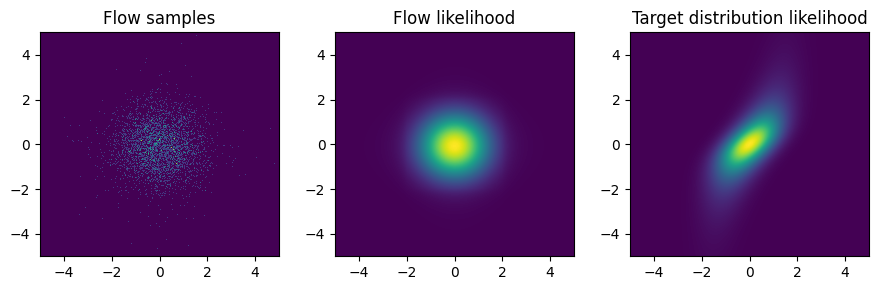

Training steps:  50%|█████     | 1500/3000 [00:59<00:20, 73.83it/s, running loss=1.83]

Computing likelihood on tensor of shape torch.Size([250000, 2])...


Training steps:  50%|█████     | 1500/3000 [01:18<00:20, 73.83it/s, running loss=1.83]

Current training loss: 1.659


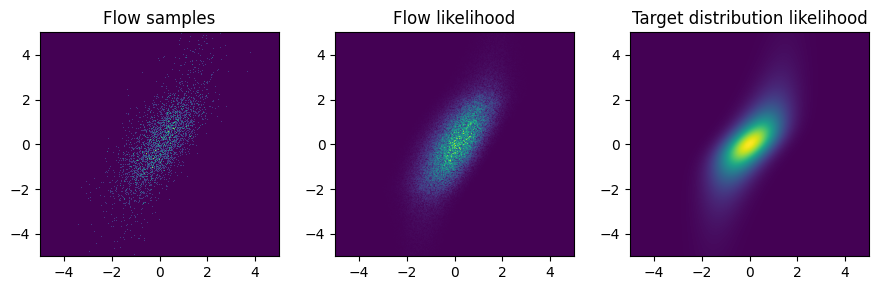

Training steps: 100%|██████████| 3000/3000 [02:09<00:00, 23.19it/s, running loss=1.81]  


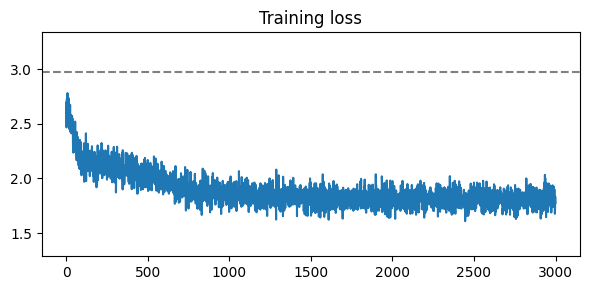

Computing likelihood on tensor of shape torch.Size([250000, 2])...


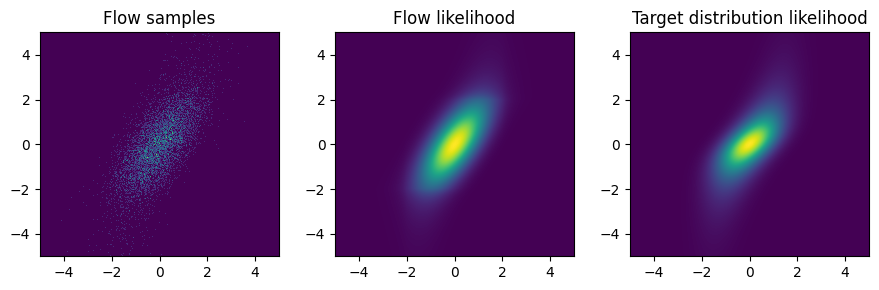

In [ ]:
fm_arcsinh_model.train(target, 3000, show_every=1500)

In [ ]:
# Compute average NLL per sample and dim
nll_fm_arcsinh = fm_arcsinh_model.get_average_nll(target, 64000)
print(f"Average NLL: {nll_fm_arcsinh:.3f}")

# Count samples in bin around 0
(avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = fm_arcsinh_model.bin_count(target, 0)
print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ± {std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} ± {std_flow_samps_in_bin_dim0:.0f}")
(avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = fm_arcsinh_model.bin_count(target, 1)
print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ± {std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} ± {std_flow_samps_in_bin_dim1:.0f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Computing likelihood on tensor of shape torch.Size([64000, 2])...


100%|██████████| 1/1 [00:29<00:00, 29.35s/it]


Average NLL: 1.498
bin (-0.100, 0.100) for dim 0:


100%|██████████| 8/8 [00:29<00:00,  3.63s/it]


Average num true samps, num flow samps in bin (dim 0): 2538 ± 45 vs 2614 ± 42
bin (-0.100, 0.100) for dim 1:


100%|██████████| 8/8 [00:28<00:00,  3.60s/it]

Average num true samps, num flow samps in bin (dim 1): 2273 ± 37 vs 1864 ± 61
